<a href="https://colab.research.google.com/github/sonkeehoon/ED-project/blob/main/05_question_type_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 id="toc">목차</h2>

1. 초기 세팅
    1. 라이브러리 불러오기
    2. 데이터 로드
2. 문제 난이도 예측
    1. Feature selection
    2. Feature 전처리
    3. Target변수 전처리
    4. 모델 학습
    5. 모델 및 Target(y) 전처리 방식 선정
    6. 특성 중요도 확인
    7. unseen 데이터 테스트
    8. 결론 및 향후 개선점

<h3 id="contents1">1. 초기 세팅</h3>

---

<h4 id="contents1-1">1-1. 라이브러리 불러오기</h4>

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid",
              palette="pastel",
              rc={
                  "font.family": "NanumGothic",
                  "axes.unicode_minus": False
              })

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from paths import CATEGORY_DATA

SEED = 42

<h4 id="contents1-2">1-2. 데이터 로드 및 전처리</h4>

---

In [ ]:
df = pd.read_csv(CATEGORY_DATA, encoding='utf-8-sig')
df

,question_number,answer,difficulty,score,accuracy_rate,option1,option2,option3,option4,option5,subject,exam_date,exam_type,ocr_text_raw,ocr_text_clean,ocr_text_tokens,ocr_has_latex,question_type,math_category
0,1,5,하,2,0.91,0.02,0.02,0.02,0.03,0.91,확률과통계,2025-05-08,학력평가,1. \( \left(3^{1-\sqrt{2}}\right)^{2} \times 9...,1. \( \left(3^{1-\sqrt{2}}\right)^{2} \times 9...,"['1', '.', '\\left', '(', '3', '^', '{', '1', ...",True,객관식,지수함수와 로그함수
1,2,1,하,2,0.91,0.91,0.02,0.02,0.04,0.02,확률과통계,2025-05-08,학력평가,2. 함수 \( f(x)=x^{3}-2 x+5 \) 에 대하여 \( \lim _{h...,2. 함수 \( f(x)=x^{3}-2 x+5 \) 에 대하여 \( \lim _{h...,"['2', '.', '함수', 'f', '(', 'x', ')', '=', 'x',...",True,객관식,미분법
2,3,3,중하,3,0.86,0.02,0.03,0.86,0.06,0.02,확률과통계,2025-05-08,학력평가,3. 첫째항과 공비가 모두 양수 \( k \) 인 등비수열 \( \left\{a_{...,3. 첫째항과 공비가 모두 양수 \( k \) 인 등비수열 \( \left\{a_{...,"['3', '.', '첫째', '항', '과', '공비', '가', '모두', '양...",True,객관식,수열
3,4,1,하,3,0.90,0.90,0.03,0.03,0.02,0.01,확률과통계,2025-05-08,학력평가,4. 함수 \( y=f(x) \) 의 그래프가 그림과 같다.\n\( \lim _{x...,4. 함수 \( y=f(x) \) 의 그래프가 그림과 같다.\n\( \lim _{x...,"['4', '.', '함수', 'y', '=', 'f', '(', 'x', ')',...",True,객관식,함수의 극한과 연속
4,5,4,하,3,0.92,0.01,0.02,0.03,0.92,0.02,확률과통계,2025-05-08,학력평가,5. 함수 \( f(x)=(2 x+1)\left(x^{2}-2 x+5\right) ...,5. 함수 \( f(x)=(2 x+1)\left(x^{2}-2 x+5\right) ...,"['5', '.', '함수', 'f', '(', 'x', ')', '=', '(',...",True,객관식,미분법
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4735,26,20,최상,4,0.25,0.00,0.00,0.00,0.00,0.00,수학(나),2016-03-10,학력평가,26. 자연수 \( n \) 에 대하여 곡선 \( y=x^{2}-\left(4+\f...,26. 자연수 \( n \) 에 대하여 곡선 \( y=x^{2}-\left(4+\f...,"['26', '.', '자연수', 'n', '에', '대하', '여', '곡선', ...",True,주관식,수열의 극한
4736,27,256,상,4,0.31,0.00,0.00,0.00,0.00,0.00,수학(나),2016-03-10,학력평가,27. 전체집합 \( U=\{x \mid x \) 는 8 이하의 자연수 \( \} ...,27. 전체집합 \( U=\{x \mid x \) 는 8 이하의 자연수 \( \} ...,"['27', '.', '전체', '집합', 'U', '=', '{', 'x', '\...",True,주관식,명제
4737,28,4,중상,4,0.52,0.00,0.00,0.00,0.00,0.00,수학(나),2016-03-10,학력평가,28. 두 함수\n\[\nf(x)=\left\{\begin{array}{ll}\nx...,28. 두 함수\n\[\nf(x)=\left\{\begin{array}{ll}\nx...,"['28', '.', '두', '함수', '\\[', 'f', '(', 'x', '...",True,주관식,합성함수/역함수
4738,29,336,중,4,0.65,0.00,0.00,0.00,0.00,0.00,수학(나),2016-03-10,학력평가,"29. 두 집합\n\[\nA=\{1,2,3,4\}, B=\{1,2,3,4,5,6,7...","29. 두 집합\n\[\nA=\{1,2,3,4\}, B=\{1,2,3,4,5,6,7...","['29', '.', '두', '집합', '\\[', 'A', '=\\{', '1'...",True,주관식,집합/함수


In [ ]:
df['math_category'].value_counts()

math_category
미분법           805
적분법           613
지수함수와 로그함수    509
수열            471
함수의 극한과 연속    365
확률            357
삼각함수          280
경우의 수         229
이차곡선          190
평면벡터          148
수열의 극한        134
통계            123
급수            119
사인/코사인법칙       95
집합/함수          60
공간도형과 공간좌표     56
무리함수/유리함수      51
합성함수/역함수       35
거듭제곱근          33
명제             33
이항분포           20
원/부채꼴           6
수학적 귀납법         4
절대부등식           3
이차함수            1
Name: count, dtype: int64

데이터에서 **표본 수가 너무 적은 클래스**는 학습 과정에서 모델의 일반화를 방해할 수 있습니다.

따라서 이번 분석에서는 **표본 수가 20 미만인 클래스는 제외**하도록 하겠습니다.

In [ ]:
tmp = df.loc[:, ['ocr_text_raw', 'math_category']]

# 제외할 클래스 목록
exclude_classes = ['이차함수', '절대부등식', '수학적 귀납법', '원/부채꼴']

# math_category에서 제외
tmp = tmp.loc[~df['math_category'].isin(exclude_classes), tmp.columns]

print("최종 클래스 개수:", tmp['math_category'].nunique())
print("데이터 개수:", len(tmp))
print()
print(tmp['math_category'].value_counts().tail())

최종 클래스 개수: 21
데이터 개수: 4726

math_category
무리함수/유리함수    51
합성함수/역함수     35
거듭제곱근        33
명제           33
이항분포         20
Name: count, dtype: int64


다시 한번 클래스 분포를 살펴봅시다

In [ ]:
tmp['math_category'].value_counts()

math_category
미분법           805
적분법           613
지수함수와 로그함수    509
수열            471
함수의 극한과 연속    365
확률            357
삼각함수          280
경우의 수         229
이차곡선          190
평면벡터          148
수열의 극한        134
통계            123
급수            119
사인/코사인법칙       95
집합/함수          60
공간도형과 공간좌표     56
무리함수/유리함수      51
합성함수/역함수       35
거듭제곱근          33
명제             33
이항분포           20
Name: count, dtype: int64

숫자가 적은 클래스는 처리가 필요해 보입니다.

'이항분포'는 '확률' 클래스에 포함시키고, '거듭제곱근'은 '지수함수와 로그함수'에 포함시키겠습니다

['집합/함수', '무리함수/유리함수', '사인/코사인법칙', '합성함수/역함수', '명제'] -> '고1/고2 공통수학' 으로 병합해보겠습니다
- 세부적인 분류를 약간은 포기한다고 가정(클래스 불균형 방지를 위해)

In [ ]:
# 매핑 딕셔너리 정의
mapping = {
    '이항분포': '확률',
    '거듭제곱근': '지수함수와 로그함수',
    '집합/함수': '고1/고2 공통수학',
    '무리함수/유리함수': '고1/고2 공통수학',
    '사인/코사인법칙': '고1/고2 공통수학',
    '합성함수/역함수': '고1/고2 공통수학',
    '명제': '고1/고2 공통수학'
}

# math_category 컬럼 값 변경
tmp['math_category'] = tmp['math_category'].replace(mapping)

# 결과 확인
tmp['math_category'].value_counts()

math_category
미분법           805
적분법           613
지수함수와 로그함수    542
수열            471
확률            377
함수의 극한과 연속    365
삼각함수          280
고1/고2 공통수학    274
경우의 수         229
이차곡선          190
평면벡터          148
수열의 극한        134
통계            123
급수            119
공간도형과 공간좌표     56
Name: count, dtype: int64

중복된 문제가 있는지 확인

In [ ]:
tmp.value_counts()

ocr_text_raw                                                                                                                                                                                                                                                                                                         math_category
9. 함수 \( f(x)=3 x^{2}-16 x-20 \) 에 대하여\n\[\n\int_{-2}^{a} f(x) d x=\int_{-2}^{0} f(x) d x\n\]\n\n일 때, 양수 \( a \) 의 값은? [4점]\n(1) 16\n(2) 14\n(3) 12\n(4) 10\n(5) 8                                                                                                                                                   적분법              3
9. 함수 \( f(x) \) 에 대하여 \( f^{\prime}(x)=3 x^{2}-4 x+1 \) 이고 \( \lim _{x \rightarrow 0} \frac{1}{x} \int_{0}^{x} f(t) d t=1 \) 일 때, \( f(2) \) 의 값은? [4점]\n(1) 3\n(2) 4\n(3) 5\n(4) 6\n(5) 7                                                                                                                          적분법              3
9. 함수\n\[\nf(x)=a-\sq

중복된 문제들은 제거해줍니다

In [ ]:
tmp = tmp.drop_duplicates()
tmp.value_counts()

ocr_text_raw                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            math_category
1. \( (-\sqrt{2})^{4} \times 8^{-\frac{2}{3}} \) 의 값은? [2점]\n(1) 1\n(2) 2\n(3) 3\n(4) 4\n(5) 5                                                                                                                                                                                                                                                                                                                                                                                                    

In [ ]:
tmp.to_csv('data/tmp.csv', encoding='utf-8-sig')

<h3 id="contents2">2. 문제 유형 자동분류</h3>

---

<h4 id="contents2-1">2-1. Feature selection</h4>

---

`시험 문제를 input` 으로 주고 `유형을 output`으로 return하는 모델을 만드는것이 목표입니다

우선 `math_category` 컬럼에 영향을 줄만한 컬럼은 시험 문제를 가장 구체적으로 설명하고 있는

`ocr_text_raw`으로 정했습니다

In [ ]:
X = tmp['ocr_text_raw']
y = tmp['math_category']

<h4 id="contents2-2">2-2. Feature 전처리</h4>

---

결측치, 앞뒤 공백 등을 처리해줍니다


In [ ]:
X.isnull().sum()

np.int64(0)

In [ ]:
X = X.str.strip()
X

0       1. \( \left(3^{1-\sqrt{2}}\right)^{2} \times 9...
1       2. 함수 \( f(x)=x^{3}-2 x+5 \) 에 대하여 \( \lim _{h...
2       3. 첫째항과 공비가 모두 양수 \( k \) 인 등비수열 \( \left\{a_{...
3       4. 함수 \( y=f(x) \) 의 그래프가 그림과 같다.\n\( \lim _{x...
4       5. 함수 \( f(x)=(2 x+1)\left(x^{2}-2 x+5\right) ...
                              ...                        
4735    26. 자연수 \( n \) 에 대하여 곡선 \( y=x^{2}-\left(4+\f...
4736    27. 전체집합 \( U=\{x \mid x \) 는 8 이하의 자연수 \( \} ...
4737    28. 두 함수\n\[\nf(x)=\left\{\begin{array}{ll}\nx...
4738    29. 두 집합\n\[\nA=\{1,2,3,4\}, B=\{1,2,3,4,5,6,7...
4739    30. 유리함수 \( f(x)=\frac{8 x}{2 x-15} \) 와 수열 \(...
Name: ocr_text_raw, Length: 3396, dtype: object

<h4 id="contents2-4">2-3. 모델 선택 및 학습</h4>

---

두가지 방식을 적용해서 비교해보려고 합니다.

1. Baseline : TF-IDF + Logistic Regression
    - 로컬 환경에서 진행 가능

2. 딥러닝 (BERT fine-tuning)
    - colab 등 클라우드 환경에서 진행 (컴퓨팅 리소스를 많이 사용하므로)

##### 1. Baseline : TF-IDF + Logistic Regression

---

In [ ]:
# 라벨(타겟)을 숫자(0, 1, 2 ..)로 인코딩
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# train/test split (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=SEED
)

# TF-IDF 벡터화 (텍스트를 숫자 벡터로 변환)
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Logistic Regression 학습
clf = LogisticRegression(max_iter=500, class_weight="balanced")
clf.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


모델 평가

In [ ]:
y_pred = clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       경우의 수       0.73      0.80      0.76        44
  고1/고2 공통수학       0.82      0.82      0.82        44
  공간도형과 공간좌표       0.67      0.91      0.77        11
          급수       0.74      0.93      0.82        15
         미분법       0.82      0.75      0.78       101
        삼각함수       0.64      0.87      0.74        31
          수열       0.94      0.89      0.92        55
      수열의 극한       0.79      0.88      0.84        26
        이차곡선       0.87      0.87      0.87        38
         적분법       0.83      0.79      0.81        75
  지수함수와 로그함수       0.92      0.87      0.89        62
          통계       0.85      0.88      0.86        25
        평면벡터       0.96      0.80      0.87        30
  함수의 극한과 연속       0.73      0.75      0.74        48
          확률       0.81      0.76      0.79        75

    accuracy                           0.82       680
   macro avg       0.81      0.84      0.82       680
weighted avg       0.82   

📊 모델 성능 평가 리포트

---
1. Classification Report

| 클래스        | Precision | Recall | F1-score | Support |
| ---------- | --------- | ------ | -------- | ------- |
| 경우의 수      | 0.73      | 0.80   | 0.76     | 44      |
| 고1/고2 공통수학 | 0.82      | 0.82   | 0.82     | 44      |
| 공간도형과 공간좌표 | 0.67      | 0.91   | 0.77     | 11      |
| 급수         | 0.74      | 0.93   | 0.82     | 15      |
| 미분법        | 0.82      | 0.75   | 0.78     | 101     |
| 삼각함수       | 0.64      | 0.87   | 0.74     | 31      |
| 수열         | 0.94      | 0.89   | 0.92     | 55      |
| 수열의 극한     | 0.79      | 0.88   | 0.84     | 26      |
| 이차곡선       | 0.87      | 0.87   | 0.87     | 38      |
| 적분법        | 0.83      | 0.79   | 0.81     | 75      |
| 지수함수와 로그함수 | 0.92      | 0.87   | 0.89     | 62      |
| 통계         | 0.85      | 0.88   | 0.86     | 25      |
| 평면벡터       | 0.96      | 0.80   | 0.87     | 30      |
| 함수의 극한과 연속 | 0.73      | 0.75   | 0.74     | 48      |
| 확률         | 0.81      | 0.76   | 0.79     | 75      |


---

2. Overall Metrics

- Accuracy: 0.82

- Macro Average (precision/recall/f1): 0.81 / 0.84 / 0.82

- Weighted Average (precision/recall/f1): 0.82 / 0.82 / 0.82

---

3. Confusion Matrix 히트맵 시각화

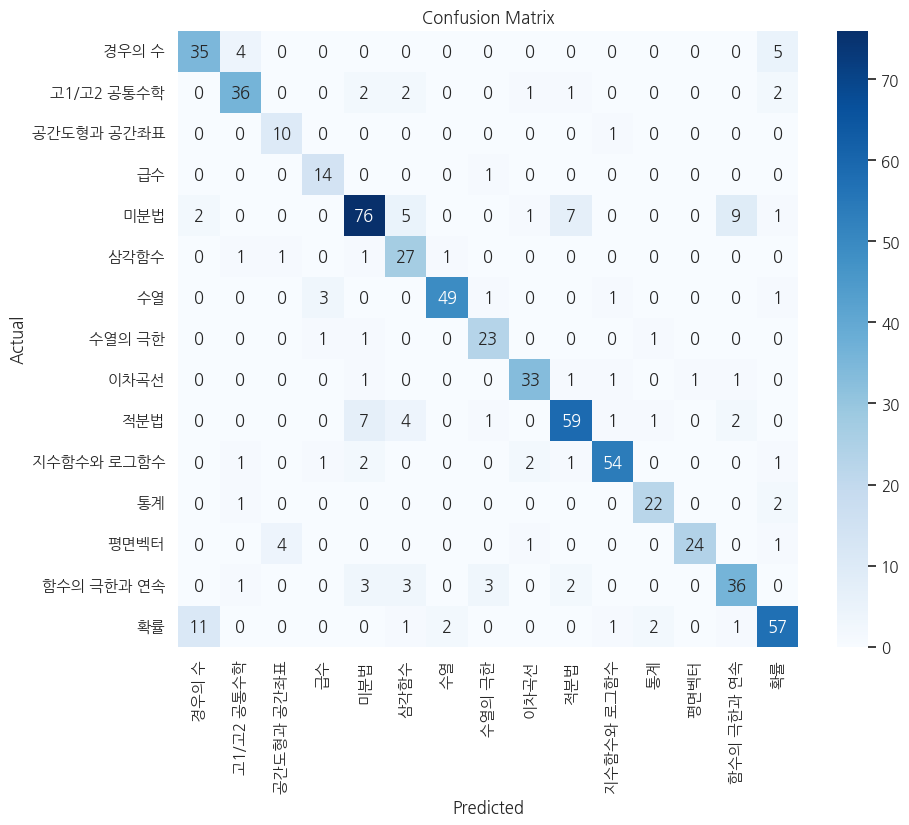

In [ ]:
cm = confusion_matrix(y_test, y_pred)

labels = le.classes_  # 히트맵의 x축, y축 인덱스를 labels로 설정

# DataFrame으로 변환
cm_df = pd.DataFrame(cm, index=le.classes_, columns=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

##### 2. 딥러닝 (KLUE-BERT fine-tuning)

---

딥러닝은 로컬 컴퓨팅 리소스의 한계로 클라우드 환경(colab)에서 작업하겠습니다

https://colab.research.google.com/drive/1aitps5USniqeHTok8DYA_BUkZ7TtDIhJ?usp=sharing

tmp.csv을 colab에서 load하고 모델링합니다 (학습 시간 약 25분 소요)

학습이 끝나면 saved_model 이라는 폴더가 만들어집니다.

이 saved_model을 통해 수학문제를 자동분류, 유사문제를 추천해주는 streamlit 웹 앱을 만들어보겠습니다.

웹 앱 구현은 아래 repo에서 이어집니다.

https://github.com/sonkeehoon/gr-math-genius